### Task 1: Load and explore the dataset

In [78]:
import matplotlib.pyplot as plt
from datasets import load_dataset
import pandas as pd

1. Load the **dataset**

In [79]:
from datasets import load_dataset

dataset = load_dataset("ag_news")
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})


2. Number of training and test samples

In [80]:
print(f"Number of training samples: {len(dataset['train'])}")
print(f"Number of test samples: {len(dataset['test'])}")

Number of training samples: 120000
Number of test samples: 7600


3. Display 5 sample articles with their labels

In [81]:
label_names = dataset["train"].features["label"].names

In [82]:
for i in range(5):
  sample = dataset['train'][i]
  print(f"\n[{i+1}] Label : {sample['label']} ({label_names[sample['label']]})")


[1] Label : 2 (Business)

[2] Label : 2 (Business)

[3] Label : 2 (Business)

[4] Label : 2 (Business)

[5] Label : 2 (Business)


4. Class distribution

In [83]:
train_df = pd.DataFrame(dataset["train"])
train_df['label_name'] = train_df['label'].map(lambda x: label_names[x])

In [84]:
distribution = train_df['label_name'].value_counts()
print(distribution)

label_name
Business    30000
Sci/Tech    30000
Sports      30000
World       30000
Name: count, dtype: int64


5. Bar chart

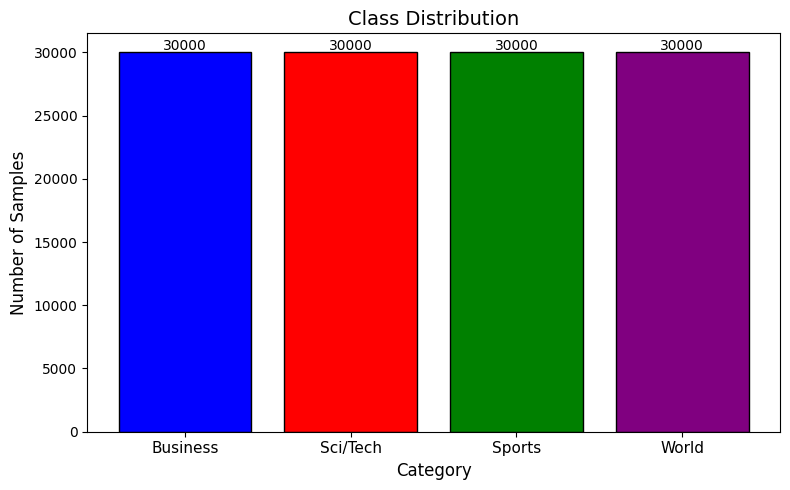

In [85]:
plt.figure(figsize=(8,5))
plt.bar(distribution.index, distribution.values,
        color=['blue', 'red', 'green', 'purple'], edgecolor='black')
plt.title('Class Distribution', fontsize=14)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.xticks(fontsize=11)
for i, v in enumerate(distribution.values):
    plt.text(i, v + 200, str(v), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

Task 2: Preprocessing

1. Extract text and label columns

In [86]:
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

In [87]:
train_texts = dataset['train']['text']
train_labels = dataset['train']['label']

In [88]:
test_texts = dataset['test']['text']
test_labels = dataset['test']['label']

2 and 3: Tokenize and limit the vocabulary to 20000 words

In [89]:
VOCAB_SIZE = 20000
MAX_LEN = 150
OOV_TOKEN = "<OOV>"

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(train_texts)

print("Total unique words:", len(tokenizer.word_index))

Total unique words: 70345


4. convert text to numerical sequences

In [90]:
train_sequences = tokenizer.texts_to_sequences(train_texts)
texts_to_sequences = tokenizer.texts_to_sequences(test_texts)

5 and 6: pad sequences and use MAX_LEN

In [91]:
X_train = pad_sequences(train_sequences, maxlen=MAX_LEN, padding='post', truncating='post')
X_test = pad_sequences(texts_to_sequences, maxlen=MAX_LEN, padding='post', truncating='post')

7. Prepare labels in the required format for multi-class classification.

In [92]:
NUM_CLASSES = 4
y_train = to_categorical(train_labels, num_classes=NUM_CLASSES)
y_test = to_categorical(test_labels, num_classes=NUM_CLASSES)


In [93]:
##Printing Shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (120000, 150)
X_test shape: (7600, 150)
y_train shape: (120000, 4)
y_test shape: (7600, 4)


Why tokenization and padding are needed?

As neural networks cannot work with raw text, tokenization is needed to convert each word into unique integer ID so model can text as numbers.

Padding is needed because RNN based models need all input sentences of same length.

Task 3: Build a Simple RNN Model

In [94]:
import time
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [95]:
EMBEDDING_DIM = 64
RNN_UNITS     = 64
EPOCHS        = 10
BATCH_SIZE    = 64

In [96]:
rnn_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    SimpleRNN(units=RNN_UNITS, activation='tanh', return_sequences=False),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(NUM_CLASSES,activation= "softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [97]:
rnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [98]:
rnn_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [99]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

In [100]:
start_time = time.time()
rnn_history = rnn_model.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_split=0.1, callbacks=[early_stop], verbose = 1)
rnn_training_time = time.time() - start_time
print("Total training time: ", rnn_training_time)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 125s 72ms/step - accuracy: 0.2522 - loss: 1.3882 - val_accuracy: 0.2657 - val_loss: 1.3860
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 125s 74ms/step - accuracy: 0.2491 - loss: 1.3863 - val_accuracy: 0.2525 - val_loss: 1.3865
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 124s 73ms/step - accuracy: 0.2487 - loss: 1.3864 - val_accuracy: 0.2384 - val_loss: 1.3867
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 125s 74ms/step - accuracy: 0.2503 - loss: 1.3864 - val_accuracy: 0.2657 - val_loss: 1.3860
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 140s 73ms/step - accuracy: 0.2501 - loss: 1.3864 - val_accuracy: 0.2521 - val_loss: 1.3865
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 114s 68ms/step - accuracy: 0.2483 - loss: 1.3863 - val_accuracy: 0.2442 - val_loss: 1.3868
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 119s 70ms/step - accuracy: 0.2516 - loss: 1.3863 - val_accuracy: 0.2442 - val_loss: 1.3862
Total training time:  871.6878581047058


In [151]:
rnn_loss, rnn_test_acc = rnn_model.evaluate(X_test, y_test, verbose=0)

print(f"  Training Accuracy   : {max(rnn_history.history['accuracy']):.2f}")
print(f"  Validation Accuracy : {max(rnn_history.history['val_accuracy']):.2f}")
print(f"  Test Accuracy       : {rnn_test_acc:.f}")
print(f"  Test Loss           : {rnn_loss:.2f}")

  Training Accuracy   : 0.25
  Validation Accuracy : 0.27


ValueError: Format specifier missing precision

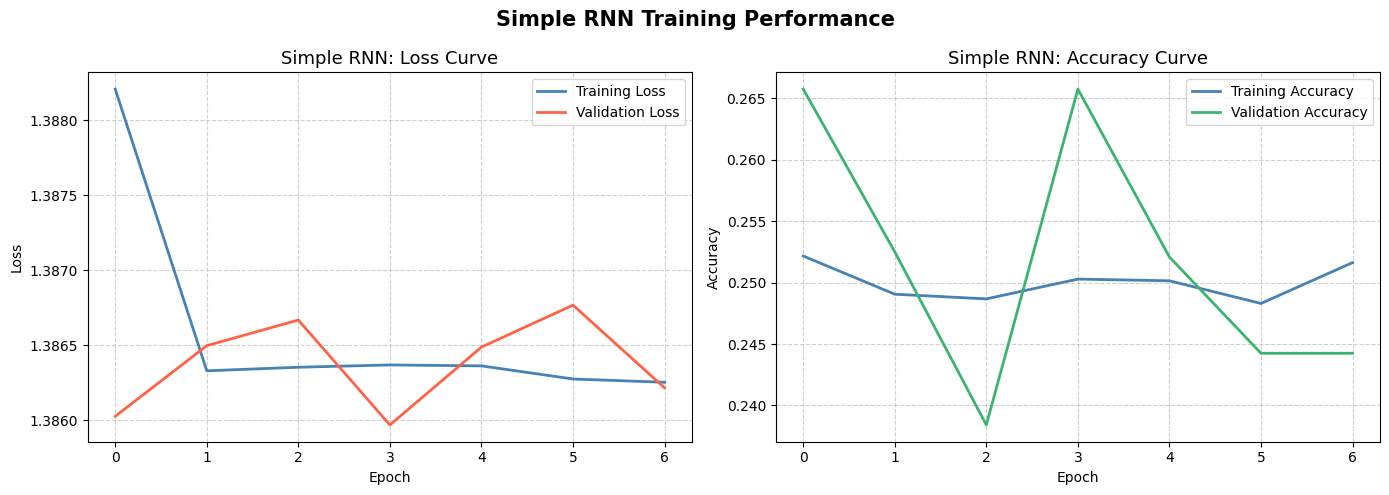

In [102]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(rnn_history.history['loss'],     label='Training Loss',   color='steelblue',  linewidth=2)
axes[0].plot(rnn_history.history['val_loss'], label='Validation Loss', color='tomato',     linewidth=2)
axes[0].set_title('Simple RNN: Loss Curve',     fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)


axes[1].plot(rnn_history.history['accuracy'],     label='Training Accuracy',   color='steelblue',     linewidth=2)
axes[1].plot(rnn_history.history['val_accuracy'], label='Validation Accuracy', color='mediumseagreen', linewidth=2)
axes[1].set_title('Simple RNN: Accuracy Curve', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.suptitle('Simple RNN Training Performance', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

Obervation: The simple RNN model failed to learn achieving only 25% test accuracy which is equal to random guessing. Even after training with 0.3 dropout and higher patience, the model showed no improvement. Simple RNN cannot remember information from earlier words in long news articles making it unsuitable for this problem statement.

Task 4: Building an LSTM model

In [103]:
import time
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [104]:
EMBEDDING_DIM = 64
LSTM_UNITS    = 64
EPOCHS        = 10
BATCH_SIZE    = 64

In [105]:
lstm_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    LSTM(units=LSTM_UNITS, return_sequences=False),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax')
])

In [106]:
lstm_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [107]:
lstm_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [108]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

In [109]:
start_time = time.time()
lstm_history = lstm_model.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_split=0.1, callbacks=[early_stop], verbose = 1)
lstm_training_time = time.time() - start_time
print("Total training time: ", lstm_training_time)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 236s 138ms/step - accuracy: 0.2513 - loss: 1.3866 - val_accuracy: 0.2442 - val_loss: 1.3875
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 229s 136ms/step - accuracy: 0.2523 - loss: 1.3865 - val_accuracy: 0.2387 - val_loss: 1.3866
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 266s 138ms/step - accuracy: 0.2511 - loss: 1.3872 - val_accuracy: 0.2386 - val_loss: 1.3862
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 264s 140ms/step - accuracy: 0.2863 - loss: 1.3261 - val_accuracy: 0.6320 - val_loss: 0.7617
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 238s 141ms/step - accuracy: 0.8049 - loss: 0.5259 - val_accuracy: 0.8920 - val_loss: 0.3548
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 255s 137ms/step - accuracy: 0.9216 - loss: 0.2797 - val_accuracy: 0.9082 - val_loss: 0.2832
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 230s 136ms/step - accuracy: 0.9419 - loss: 0.2106 - val_accuracy: 0.9096 - val_loss: 0.2851
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 248s 147ms/step - ac

In [110]:
lstm_loss, lstm_test_acc = lstm_model.evaluate(X_test, y_test, verbose=0)

In [111]:
print(f"  Training Accuracy   : {max(lstm_history.history['accuracy']):.2f}")
print(f"  Validation Accuracy : {max(lstm_history.history['val_accuracy']):.2f}")
print(f"  Test Accuracy       : {lstm_test_acc:.2f}")
print(f"  Test Loss           : {lstm_loss:.2f}")

  Training Accuracy   : 0.96
  Validation Accuracy : 0.91
  Test Accuracy       : 0.91
  Test Loss           : 0.30


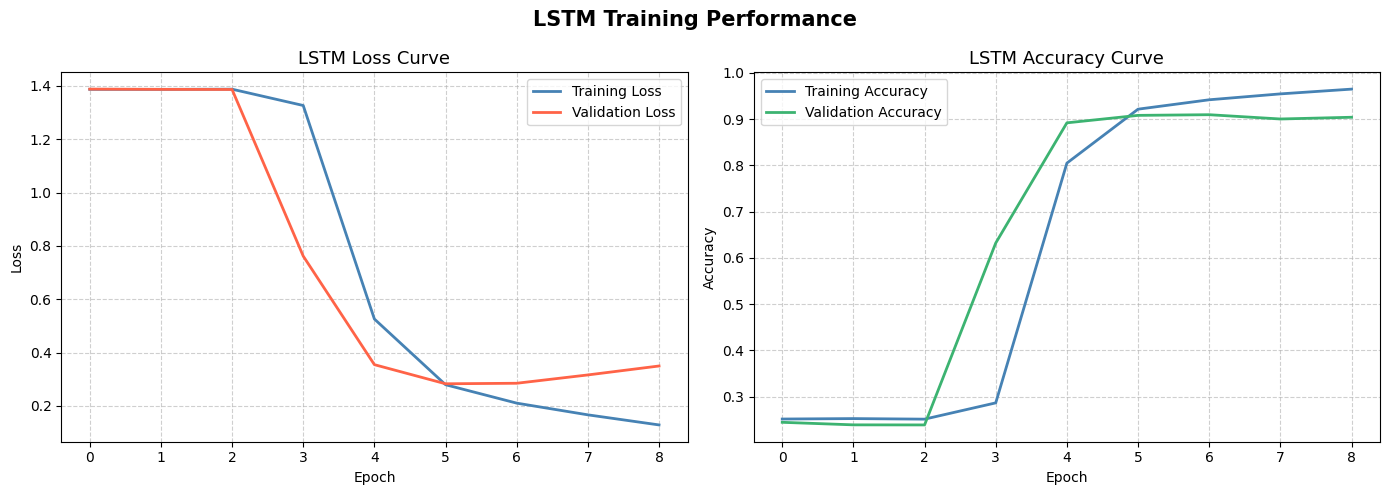

In [112]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(lstm_history.history['loss'],     label='Training Loss',   color='steelblue', linewidth=2)
axes[0].plot(lstm_history.history['val_loss'], label='Validation Loss', color='tomato',    linewidth=2)
axes[0].set_title('LSTM Loss Curve',     fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)


axes[1].plot(lstm_history.history['accuracy'],     label='Training Accuracy',   color='steelblue',      linewidth=2)
axes[1].plot(lstm_history.history['val_accuracy'], label='Validation Accuracy', color='mediumseagreen', linewidth=2)
axes[1].set_title('LSTM Accuracy Curve', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)


plt.suptitle('LSTM Training Performance', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

Observation: The LSTM model performed well achieving a test accuracy of 91%, which is far more better than simple RNN (25%). However 96% of validation accuracy means there is slight overfitting. The test loss 0.30 confirms model is making correct predictions. Overall its far more better than Simple RNN

Task 5: building GRU model

In [113]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout

In [114]:
EMBEDDING_DIM = 64
GRU_UNITS = 64
EPOCHS = 10
BATCH_SIZE = 64

In [115]:
gru_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE,
              output_dim=EMBEDDING_DIM,
              input_length=MAX_LEN),
    GRU(GRU_UNITS,
    return_sequences=False),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax')
])

In [116]:
gru_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [117]:
gru_model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [118]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

In [119]:
start_time = time.time()
gru_history = gru_model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)
gru_training_time = time.time() - start_time


Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 297s 173ms/step - accuracy: 0.2508 - loss: 1.3866 - val_accuracy: 0.2386 - val_loss: 1.3871
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 269s 160ms/step - accuracy: 0.2492 - loss: 1.3880 - val_accuracy: 0.2442 - val_loss: 1.3898
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 318s 157ms/step - accuracy: 0.5424 - loss: 0.9933 - val_accuracy: 0.8901 - val_loss: 0.3698
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 264s 156ms/step - accuracy: 0.9113 - loss: 0.3231 - val_accuracy: 0.9138 - val_loss: 0.2635
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 327s 159ms/step - accuracy: 0.9365 - loss: 0.2303 - val_accuracy: 0.9136 - val_loss: 0.2609
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 266s 158ms/step - accuracy: 0.9498 - loss: 0.1775 - val_accuracy: 0.9103 - val_loss: 0.2924
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 267s 158ms/step - accuracy: 0.9613 - loss: 0.1321 - val_accuracy: 0.9038 - val_loss: 0.3325
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 267s 158ms/step - ac

In [120]:
gru_loss, gru_test_acc = gru_model.evaluate(X_test, y_test, verbose=0)

In [ ]:
print(f"Training Accuracy   : {max(gru_history.history['accuracy']):.2f}")
print(f"Validation Accuracy : {max(gru_history.history['val_accuracy']):.2f}")
print(f"Test Accuracy       : {gru_test_acc:.2f}")
print(f"Test Loss           : {gru_loss:.2f}")


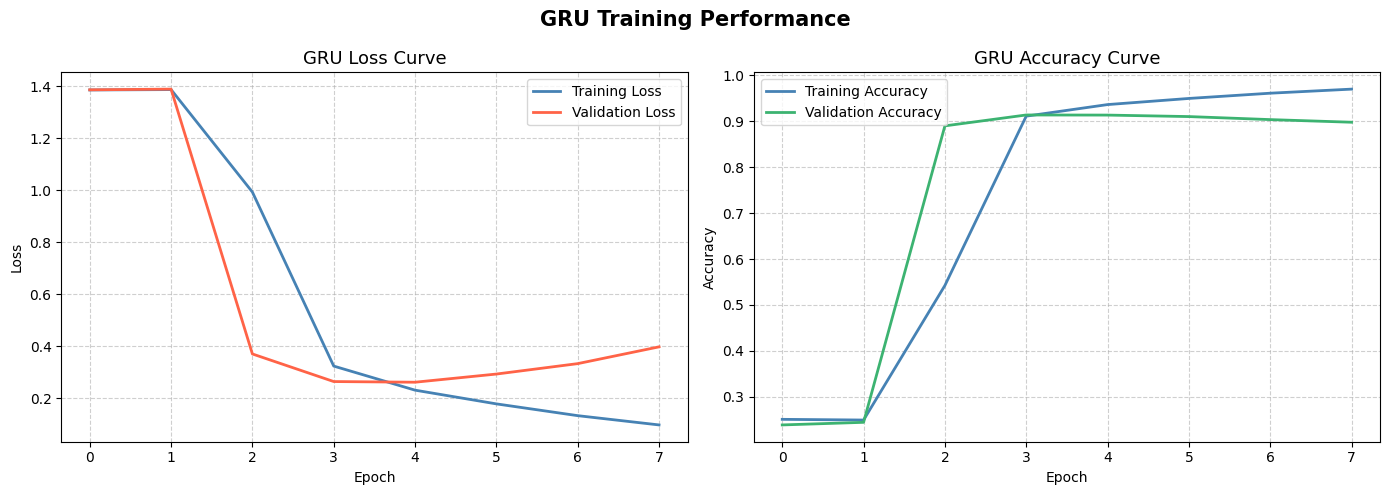

In [122]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(gru_history.history['loss'],     label='Training Loss',   color='steelblue', linewidth=2)
axes[0].plot(gru_history.history['val_loss'], label='Validation Loss', color='tomato',    linewidth=2)
axes[0].set_title('GRU Loss Curve',     fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].plot(gru_history.history['accuracy'],     label='Training Accuracy',   color='steelblue',      linewidth=2)
axes[1].plot(gru_history.history['val_accuracy'], label='Validation Accuracy', color='mediumseagreen', linewidth=2)
axes[1].set_title('GRU Accuracy Curve', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.suptitle('GRU Training Performance', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

Observations: Gru model achieved 91.6% accuracy slightly better than LSTM. However validation accuracy is 97% shows overfitting similar to LSTM. Test loss 0.27 is slightly lesser than LSTM, which means GRU makes marginally better predictions compared to LSTM.

Task 6 Bidirectional LSTM model

In [123]:
import time
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [124]:
EMBEDDING_DIM = 64
LSTM_UNITS    = 64
EPOCHS        = 10
BATCH_SIZE    = 64

In [125]:
bilstm_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE,
              output_dim=EMBEDDING_DIM,
              input_length=MAX_LEN),

    Bidirectional(LSTM(LSTM_UNITS,
                  return_sequences=False)),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax')
])

In [126]:
bilstm_model.compile(optimizer='adam',
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

In [127]:
bilstm_model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [128]:
early_stop = EarlyStopping(monitor='val_loss',
                           patience=3,
                           restore_best_weights=True)

In [129]:
start_time = time.time()

bilstm_history = bilstm_model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

bilstm_training_time = time.time() - start_time

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 435s 253ms/step - accuracy: 0.8760 - loss: 0.3562 - val_accuracy: 0.9095 - val_loss: 0.2542
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 410s 243ms/step - accuracy: 0.9340 - loss: 0.2000 - val_accuracy: 0.9133 - val_loss: 0.2487
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 402s 238ms/step - accuracy: 0.9472 - loss: 0.1544 - val_accuracy: 0.9069 - val_loss: 0.2792
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 451s 244ms/step - accuracy: 0.9568 - loss: 0.1218 - val_accuracy: 0.9025 - val_loss: 0.3115
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 442s 244ms/step - accuracy: 0.9649 - loss: 0.0962 - val_accuracy: 0.8994 - val_loss: 0.3411


In [130]:
bilstm_loss, bilstm_test_acc = bilstm_model.evaluate(X_test, y_test, verbose=0)

In [131]:
print(f"  Training Accuracy   : {max(bilstm_history.history['accuracy']):.2f}")
print(f"  Validation Accuracy : {max(bilstm_history.history['val_accuracy']):.2f}")
print(f"  Test Accuracy       : {bilstm_test_acc:.2f}")
print(f"  Test Loss           : {bilstm_loss:.2f}")

  Training Accuracy   : 0.96
  Validation Accuracy : 0.91
  Test Accuracy       : 0.92
  Test Loss           : 0.25


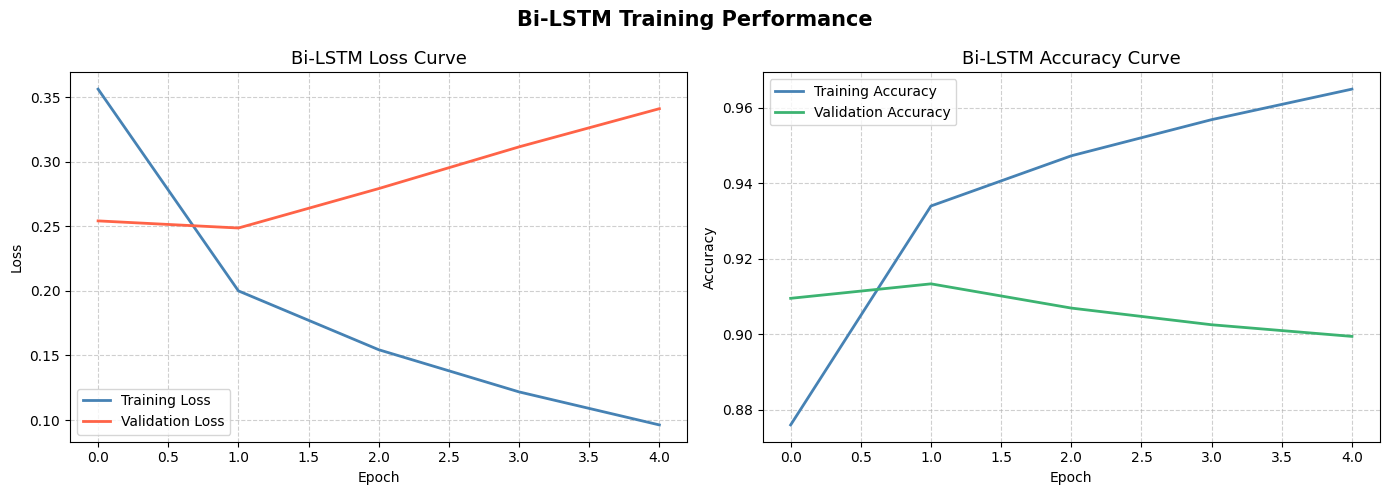

In [132]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(bilstm_history.history['loss'],     label='Training Loss',   color='steelblue', linewidth=2)
axes[0].plot(bilstm_history.history['val_loss'], label='Validation Loss', color='tomato',    linewidth=2)
axes[0].set_title('Bi-LSTM Loss Curve',     fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].plot(bilstm_history.history['accuracy'],     label='Training Accuracy',   color='steelblue',      linewidth=2)
axes[1].plot(bilstm_history.history['val_accuracy'], label='Validation Accuracy', color='mediumseagreen', linewidth=2)
axes[1].set_title('Bi-LSTM Accuracy Curve', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.suptitle('Bi-LSTM Training Performance', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

Observation: The Bi directional LSTM model acheived best test accuracy of 92% and lowest test score of 0.25. Training accuracy of 96% and 91% validation accuracy means mild overfitting which is consistent with GRU and LSTM model.

Task 7: Gradient clipping

In [133]:
import time
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

In [134]:
EMBEDDING_DIM = 64
LSTM_UNITS    = 64
EPOCHS        = 10
BATCH_SIZE    = 64

In [135]:
model_no_clip = Sequential([
    Embedding(input_dim=VOCAB_SIZE,
              output_dim=EMBEDDING_DIM,
              input_length=MAX_LEN),

    LSTM(LSTM_UNITS, return_sequences=False),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(NUM_CLASSES, activation='softmax')
])

In [136]:
model_no_clip.compile(
    optimizer=Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [137]:
model_no_clip.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_10 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [138]:
early_stop = EarlyStopping(monitor='val_loss',
                           patience=3,
                           restore_best_weights=True)

In [139]:
history_no_clip = model_no_clip.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

time_no_clip = time.time() - start_time

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 246s 144ms/step - accuracy: 0.2525 - loss: 1.3866 - val_accuracy: 0.2522 - val_loss: 1.3861
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 233s 138ms/step - accuracy: 0.2492 - loss: 1.3886 - val_accuracy: 0.2382 - val_loss: 1.3864
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 263s 139ms/step - accuracy: 0.2503 - loss: 1.3864 - val_accuracy: 0.2382 - val_loss: 1.3865
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 230s 136ms/step - accuracy: 0.2497 - loss: 1.3863 - val_accuracy: 0.2521 - val_loss: 1.3864


In [140]:
loss_no_clip, acc_no_clip = model_no_clip.evaluate(X_test, y_test, verbose=0)

In [ ]:
print(f"Test Accuracy (No Clipping) : {acc_no_clip:.2f}")
print(f"Test Loss    (No Clipping)  : {loss_no_clip:.2f}")

MODEL WITH CLIP

In [142]:
model_with_clip = Sequential([
    Embedding(input_dim=VOCAB_SIZE,
              output_dim=EMBEDDING_DIM,
              input_length=MAX_LEN),

    LSTM(LSTM_UNITS, return_sequences=False),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(NUM_CLASSES, activation='softmax')
])

In [143]:
model_with_clip.compile(
    optimizer=Adam(clipnorm=1.0),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [144]:
model_with_clip.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_11 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [145]:
early_stop = EarlyStopping(monitor='val_loss',
                           patience=3,
                           restore_best_weights=True)

In [146]:
start_time = time.time()

history_with_clip = model_with_clip.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

time_with_clip = time.time() - start_time

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 234s 136ms/step - accuracy: 0.2509 - loss: 1.3866 - val_accuracy: 0.2654 - val_loss: 1.3858
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 229s 136ms/step - accuracy: 0.2474 - loss: 1.3865 - val_accuracy: 0.2659 - val_loss: 1.3859
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 266s 139ms/step - accuracy: 0.2506 - loss: 1.3862 - val_accuracy: 0.2442 - val_loss: 1.3858
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 229s 136ms/step - accuracy: 0.4742 - loss: 1.0511 - val_accuracy: 0.8906 - val_loss: 0.3507
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 261s 135ms/step - accuracy: 0.9155 - loss: 0.2889 - val_accuracy: 0.9136 - val_loss: 0.2550
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 265s 137ms/step - accuracy: 0.9416 - loss: 0.2008 - val_accuracy: 0.9111 - val_loss: 0.2784
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 229s 136ms/step - accuracy: 0.9565 - loss: 0.1484 - val_accuracy: 0.9102 - val_loss: 0.2860
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 228s 135ms/step - ac

In [147]:
loss_with_clip, acc_with_clip = model_with_clip.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy (With Clipping) : {acc_with_clip:.2f}")
print(f"Test Loss    (With Clipping)  : {loss_with_clip:.2f}")

Test Accuracy (With Clipping) : 0.9128
Test Loss    (With Clipping)  : 0.2789


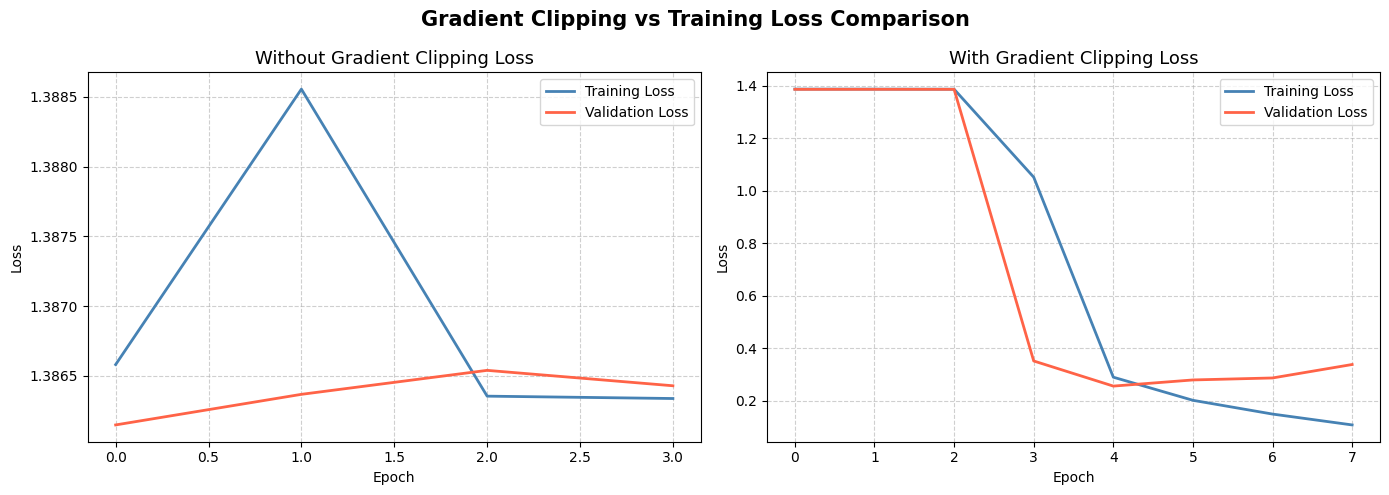

In [148]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_no_clip.history['loss'],     label='Training Loss',   color='steelblue', linewidth=2)
axes[0].plot(history_no_clip.history['val_loss'], label='Validation Loss', color='tomato',    linewidth=2)
axes[0].set_title('Without Gradient Clipping Loss', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].plot(history_with_clip.history['loss'],     label='Training Loss',   color='steelblue', linewidth=2)
axes[1].plot(history_with_clip.history['val_loss'], label='Validation Loss', color='tomato',    linewidth=2)
axes[1].set_title('With Gradient Clipping Loss',    fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.suptitle('Gradient Clipping vs Training Loss Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

Observation: The model without gradient clipping failed completely, achieving only 25% accuracy. And the model with gradient clipping performed better with 91.28% accuracy and 0.27 test loss.

Task 8: Comparing all models

In [149]:
results = {
    'Model': ['Simple RNN', 'LSTM', 'GRU', 'Bi-LSTM'],
    'Training Accuracy': [
        round(max(rnn_history.history['accuracy']), 4),
        round(max(lstm_history.history['accuracy']), 4),
        round(max(gru_history.history['accuracy']), 4),
        round(max(bilstm_history.history['accuracy']), 4)
    ],
    'Validation Accuracy': [
        round(max(rnn_history.history['val_accuracy']), 4),
        round(max(lstm_history.history['val_accuracy']), 4),
        round(max(gru_history.history['val_accuracy']), 4),
        round(max(bilstm_history.history['val_accuracy']), 4)
    ],
    'Test Accuracy': [
        round(rnn_test_acc, 4),
        round(lstm_test_acc, 4),
        round(gru_test_acc, 4),
        round(bilstm_test_acc, 4)
    ],
    'Training Time (s)': [
        round(rnn_training_time, 2),
        round(lstm_training_time, 2),
        round(gru_training_time, 2),
        round(bilstm_training_time, 2)
    ],
    'Key Observation': [
        'Baseline model, struggles with long-range dependencies',
        'Captures long-range dependencies using memory gates',
        'Faster than LSTM, comparable accuracy',
        'Uses both forward and backward context'
    ]
}

df_results = pd.DataFrame(results)

Training time comparison

In [150]:
df_results

,Model,Training Accuracy,Validation Accuracy,Test Accuracy,Training Time (s),Key Observation
0,Simple RNN,0.2522,0.2657,0.2500,871.69,"Baseline model, struggles with long-range depe..."
1,LSTM,0.9649,0.9096,0.9117,2202.64,Captures long-range dependencies using memory ...
2,GRU,0.9701,0.9138,0.9163,2275.49,"Faster than LSTM, comparable accuracy"
3,Bi-LSTM,0.9649,0.9133,0.9184,2141.06,Uses both forward and backward context


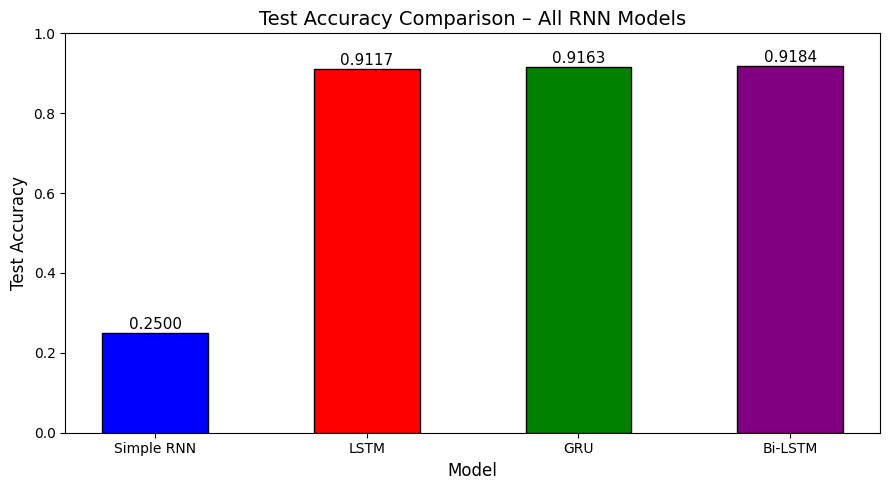

In [153]:
models    = ['Simple RNN', 'LSTM', 'GRU', 'Bi-LSTM']
test_accs = [0.2500, 0.9117, 0.9163, 0.9184]
colors    = ['blue', 'red', 'green', 'purple']


plt.figure(figsize=(9, 5))
bars = plt.bar(models, test_accs, color=colors, edgecolor='black', width=0.5)
plt.title('Test Accuracy Comparison – All RNN Models', fontsize=14)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.ylim(0, 1)
for bar, acc in zip(bars, test_accs):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.01,
             f'{acc:.4f}', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

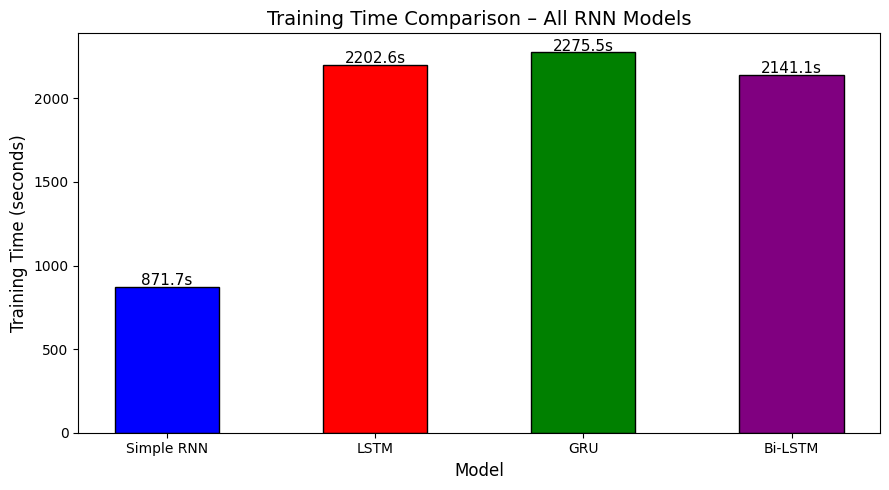

In [155]:
plt.figure(figsize=(9, 5))
bars = plt.bar(models, times, color=colors, edgecolor='black', width=0.5)
plt.title('Training Time Comparison – All RNN Models', fontsize=14)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Training Time (seconds)', fontsize=12)
for bar, t in zip(bars, times):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 10,
             f'{t:.1f}s', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

Final conclusion:


1. Best test accuracy:

Bi LSTM achieved the highest accuracy 91.84% followed closely by GRU and LSTM.


2. Simple RNN vs LSTM and GRU:
Simple RNN completely failed with 25% accuracy. LSTM and GRU both solved the problem with 91% accuracy.

3. Did Bi-LSTM improve performance?
Yes Bi LSTM did improve performance slightly.

4. Did Gradient Clipping help?
Yes gradient clipping helped. Without clipping, the model scored 25% and with clipping it jumped to 91.28%.

5. Recommended Model:
Bi LSTM is the most recommended model for this dataset. It achieves the best test accuracy, lowest test loss and benefits from bi directional context.